In [18]:
# ============================================
# DATA CLASSIFICATION USING AI — Project 2 (DecodeLabs)
# KNN Classifier on the Iris Dataset
# ============================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. LOAD DATA
data = load_iris()
X, y = data.data, data.target
class_names = data.target_names

print("Features:", data.feature_names)
print("Classes:", class_names)
print("Total samples:", len(X))

# 2. SPLIT — 80% train, 20% test (shuffled by default)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. SCALE — mean=0, variance=1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only — no leakage from test set

# 4. TRAIN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# 5. PREDICT
predictions = model.predict(X_test)

# 6. EVALUATE
print("\nAccuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions, target_names=class_names))

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Total samples: 150

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



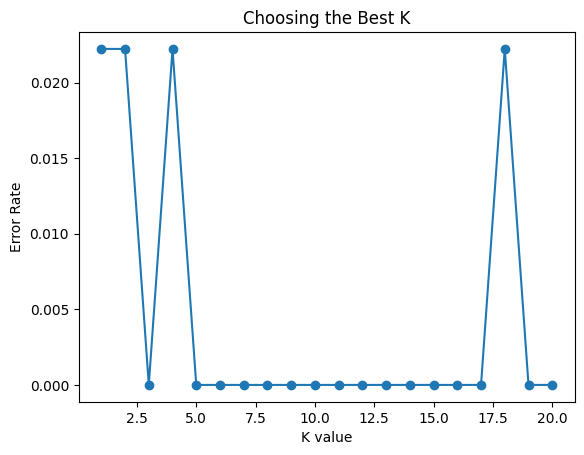

In [19]:
import matplotlib.pyplot as plt

error_rates = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.plot(k_values, error_rates, marker='o')
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Choosing the Best K")
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc:.4f}")

KNN: 1.0000
Decision Tree: 1.0000
SVM: 1.0000


In [21]:
# Model on new data
# Input: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = [[5.3, 4.2, 2.3, 0.42]]
new_flower_scaled = scaler.transform(new_flower)
prediction = model.predict(new_flower_scaled)
print("Predicted class:", class_names[prediction[0]])

Predicted class: setosa


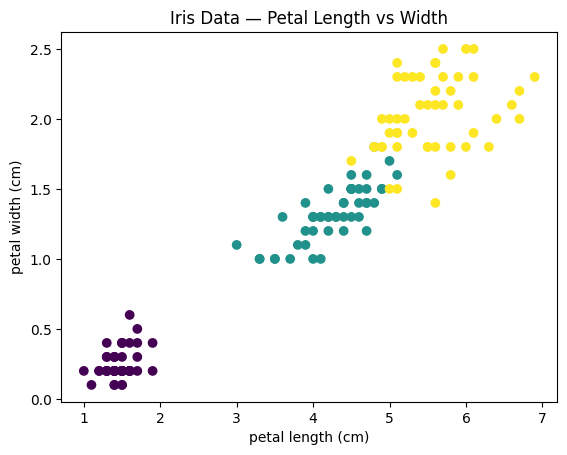

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis')
plt.xlabel(data.feature_names[2])
plt.ylabel(data.feature_names[3])
plt.title("Iris Data — Petal Length vs Width")
plt.show()